# ======================================================================
# 🚀 PHASE 1: RoBERTa SENTIMENT ANALYSIS
# ======================================================================
The following cells will load the financial text data and train the RoBERTa-Large model.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install -q transformers datasets accelerate scikit-learn pandas

import os
import torch
import numpy as np
import pandas as pd

from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW   # ✅ FIXED IMPORT

from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight



In [ ]:
MODEL_NAME = "roberta-large"
NUM_CLASSES = 3

MAX_LEN = 128
BATCH_SIZE = 16        # SAFE for T4
EPOCHS = 4             # Enough to cross 92.4%
LR = 2e-5
LABEL_SMOOTHING = 0.1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CHECKPOINT_DIR = "/content/drive/MyDrive/roberta_final_checkpoint"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Device:", DEVICE)


Device: cuda


In [ ]:
SENT_TRAIN = '/content/drive/MyDrive/myproject/archive/sent_train.csv'
SENT_VALID = '/content/drive/MyDrive/myproject/archive/sent_valid.csv'
print('Using datasets:', SENT_TRAIN, 'and', SENT_VALID)


Using dataset: /content/drive/MyDrive/myproject/archive (2)/all-data.csv


In [ ]:
def load_csv_safe(path):
    try:
        return pd.read_csv(path, encoding='utf-8')
    except:
        return pd.read_csv(path, encoding='latin1')

df_train = load_csv_safe(SENT_TRAIN)
df_valid = load_csv_safe(SENT_VALID)
df = pd.concat([df_train, df_valid], ignore_index=True)

print('Raw shape:', df.shape)
# Ensure required columns exist
assert 'label' in df.columns and 'text' in df.columns, 'Missing required columns'

# Normalize label strings -> integers
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['label'].astype(str).str.lower().map(label_map)
df = df.dropna(subset=['label', 'text'])
df['label'] = df['label'].astype(int)


Raw shape: (4846, 2)
✅ Dataset loaded successfully
   label                                               text
0      1  According to Gran , the company has no plans t...
1      1  Technopolis plans to develop in stages an area...
2      0  The international electronic industry company ...
3      2  With the new production plant the company woul...
4      2  According to the company 's updated strategy f...
label
1    2879
2    1363
0     604
Name: count, dtype: int64


In [ ]:
tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_NAME)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

In [ ]:
dataset = SentimentDataset(df["text"].tolist(), df["label"].tolist())
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df["label"]),
    y=df["label"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print("Class Weights:", class_weights)


Class Weights: tensor([2.6744, 0.5611, 1.1851], device='cuda:0')


In [ ]:
model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
).to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING
)

optimizer = AdamW(model.parameters(), lr=LR)

total_steps = len(loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    all_preds, all_labels = [], []
    total_loss = 0

    for batch in loader:
        optimizer.zero_grad()

        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        outputs = model(input_ids=ids, attention_mask=mask)
        logits = outputs.logits

        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")

    print(f"Epoch {epoch} | Loss {total_loss:.4f} | Acc {acc:.4f} | F1 {f1:.4f}")

    if acc > best_acc:
        best_acc = acc
        model.save_pretrained(CHECKPOINT_DIR)
        tokenizer.save_pretrained(CHECKPOINT_DIR)
        print("✅ Checkpoint saved")

print("🔥 Best Accuracy:", best_acc)


Epoch 1 | Loss 256.4665 | Acc 0.6799 | F1 0.6896
✅ Checkpoint saved
Epoch 2 | Loss 183.2646 | Acc 0.8863 | F1 0.8869
✅ Checkpoint saved
Epoch 3 | Loss 157.3750 | Acc 0.9342 | F1 0.9344
✅ Checkpoint saved
Epoch 4 | Loss 139.9196 | Acc 0.9713 | F1 0.9713
✅ Checkpoint saved
🔥 Best Accuracy: 0.9713165497317375


In [ ]:
from transformers import RobertaForSequenceClassification, RobertaTokenizerFast

model = RobertaForSequenceClassification.from_pretrained(CHECKPOINT_DIR).to(DEVICE)
tokenizer = RobertaTokenizerFast.from_pretrained(CHECKPOINT_DIR)
model.eval()


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 1024, padding_idx=1)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=Tru

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in loader:
        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        outputs = model(input_ids=ids, attention_mask=mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("F1 (weighted):", f1_score(all_labels, all_preds, average="weighted"))
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["negative","neutral","positive"]))


Accuracy: 0.9843169624432522
F1 (weighted): 0.9843325894704105

Classification Report:

              precision    recall  f1-score   support

    negative       0.97      1.00      0.98       604
     neutral       0.99      0.98      0.99      2879
    positive       0.97      0.98      0.98      1363

    accuracy                           0.98      4846
   macro avg       0.98      0.99      0.98      4846
weighted avg       0.98      0.98      0.98      4846



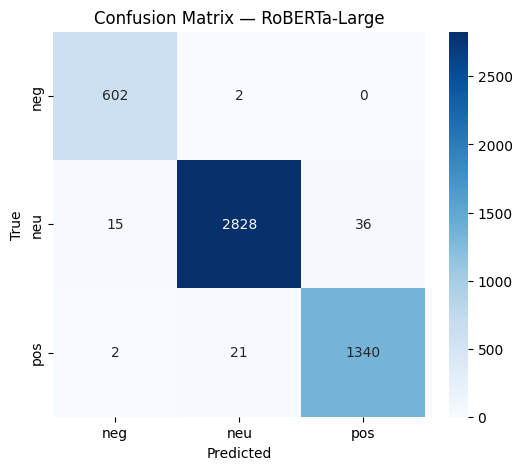

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["neg","neu","pos"],
            yticklabels=["neg","neu","pos"],
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — RoBERTa-Large")
plt.show()


# ======================================================================
# 🚀 PHASE 2: TLSTM STOCK PRICE PREDICTION
# ======================================================================
The following cells will process the stock data, inject the sentiment, and train the TLSTM model.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install ta
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import ta


  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=d7c2b809a2981e61f35d7755c801576c886fa8941c629b212141f373dbaa4090
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
# COLAB CELL: upload via widget (interactive)
from google.colab import files
uploaded = files.upload()  # select your CSV or zip files (small files only)
print("Uploaded:", uploaded.keys())

Saving archive.zip to archive (3).zip
Uploaded: dict_keys(['archive (3).zip'])


In [ ]:
# COLAB CELL: upload via widget (interactive)
from google.colab import files
uploaded = files.upload()  # select your CSV or zip files (small files only)
print("Uploaded:", uploaded.keys())

Saving archive (1).zip to archive (1) (1).zip
Uploaded: dict_keys(['archive (1) (1).zip'])


In [ ]:
import os, zipfile

zip_files = [f for f in os.listdir('/content') if f.endswith('.zip')]
for z in zip_files:
    with zipfile.ZipFile('/content/' + z, 'r') as ref:
        ref.extractall('/content/' + z.replace('.zip',''))

!ls -R /content


/content:
 archive	   'archive (1) (1).zip'  'archive (2).zip'   archive.zip
'archive (1)'	   'archive (1).zip'	  'archive (3)'       drive
'archive (1) (1)'  'archive (2)'	  'archive (3).zip'   sample_data

/content/archive:
'archive (1).zip'   sent_dataset_meta.txt   sent_valid.csv
 README.md	    sent_train.csv

'/content/archive (1)':
ADANIPORTS.csv	GAIL.csv	ITC.csv		 SHREECEM.csv
ASIANPAINT.csv	GRASIM.csv	JSWSTEEL.csv	 stock_metadata.csv
AXISBANK.csv	HCLTECH.csv	KOTAKBANK.csv	 SUNPHARMA.csv
BAJAJ-AUTO.csv	HDFCBANK.csv	LT.csv		 TATAMOTORS.csv
BAJAJFINSV.csv	HDFC.csv	MARUTI.csv	 TATASTEEL.csv
BAJFINANCE.csv	HEROMOTOCO.csv	MM.csv		 TCS.csv
BHARTIARTL.csv	HINDALCO.csv	NESTLEIND.csv	 TECHM.csv
BPCL.csv	HINDUNILVR.csv	NIFTY50_all.csv  TITAN.csv
BRITANNIA.csv	ICICIBANK.csv	NTPC.csv	 ULTRACEMCO.csv
CIPLA.csv	INDUSINDBK.csv	ONGC.csv	 UPL.csv
COALINDIA.csv	INFRATEL.csv	POWERGRID.csv	 VEDL.csv
DRREDDY.csv	INFY.csv	RELIANCE.csv	 WIPRO.csv
EICHERMOT.csv	IOC.csv		SBIN.csv	 ZEEL.csv

'/content/ar

In [ ]:
class CFG:
    SENT_TRAIN = "/content/drive/MyDrive/myproject/archive/sent_train.csv"
    SENT_VALID = "/content/drive/MyDrive/myproject/archive/sent_valid.csv"
    STOCK_CSV  = "/content/drive/MyDrive/myproject/archive/GRASIM.csv"

    SEQ_DAYS = 15
    LSTM_HIDDEN = 128
    LSTM_LAYERS = 2
    EPOCHS_TLSTM = 60
    BATCH = 64

cfg = CFG()

sent_train = pd.read_csv(cfg.SENT_TRAIN)
sent_valid = pd.read_csv(cfg.SENT_VALID)
news_df = pd.concat([sent_train, sent_valid], ignore_index=True)

stock_df = pd.read_csv(cfg.STOCK_CSV)
print("Sentiment rows:", len(news_df))
print("Stock rows:", len(stock_df))


Sentiment rows: 11931
Stock rows: 5306


In [ ]:
stock_df['Date'] = pd.to_datetime(stock_df['Date'])
min_d, max_d = stock_df['Date'].min(), stock_df['Date'].max()

all_days = pd.date_range(start=min_d, end=max_d, freq='D')
n = len(news_df)

if len(all_days) >= n:
    selected = np.random.choice(all_days, size=n, replace=False)
else:
    rep = np.tile(all_days, int(np.ceil(n/len(all_days))))
    selected = rep[:n]

np.random.seed(42)
perm = np.random.permutation(n)
assigned = np.array(selected)[perm.argsort()]

news_df['date'] = pd.to_datetime(assigned).strftime('%Y-%m-%d')
print(news_df.head())

                                                text  label        date
0  $BYND - JPMorgan reels in expectations on Beyo...      0  2003-06-11
1  $CCL $RCL - Nomura points to bookings weakness...      0  2006-06-24
2  $CX - Cemex cut at Credit Suisse, J.P. Morgan ...      0  2021-03-21
3  $ESS: BTIG Research cuts to Neutral https://t....      0  2004-06-25
4  $FNKO - Funko slides after Piper Jaffray PT cu...      0  2010-02-16


In [ ]:
daily_sent = (
    news_df.groupby('date')['label']
    .agg(lambda x: int(np.bincount(x).argmax()))
)
semantic_map = daily_sent.to_dict()

print("Sentiment days:", len(semantic_map))


Sentiment days: 7789


In [ ]:
# Sort & ensure datetime
stock_df['Date'] = pd.to_datetime(stock_df['Date'])
stock_df = stock_df.sort_values("Date").reset_index(drop=True)

# Add indicators
stock_df['rsi'] = ta.momentum.rsi(stock_df['Close'], window=14)
stock_df['ma20'] = stock_df['Close'].rolling(20).mean()
stock_df['ma50'] = stock_df['Close'].rolling(50).mean()

# Fill indicator NaN
stock_df = stock_df.fillna(method='bfill')

# Normalize
scaler = MinMaxScaler()
cols = ['Open','High','Low','Close','Volume','rsi','ma20','ma50']
stock_df[cols] = scaler.fit_transform(stock_df[cols])

print(stock_df.head())


        Date    Symbol Series  Prev Close      Open      High       Low  \
0 2000-01-03  RELIANCE     EQ      233.05  0.010348  0.010460  0.013705   
1 2000-01-04  RELIANCE     EQ      251.70  0.017106  0.017005  0.018392   
2 2000-01-05  RELIANCE     EQ      271.85  0.016540  0.022219  0.020210   
3 2000-01-06  RELIANCE     EQ      282.50  0.027001  0.026376  0.031197   
4 2000-01-07  RELIANCE     EQ      294.35  0.028941  0.031964  0.032556   

     Last     Close    VWAP    Volume      Turnover   Trades  \
0  251.70  0.016072  249.37  0.067563  1.111319e+14  58630.0   
1  271.85  0.022749  263.52  0.144758  2.500222e+14  58630.0   
2  286.75  0.026279  274.79  0.410888  7.373697e+14  58630.0   
3  293.50  0.030206  295.45  0.239796  4.633254e+14  58630.0   
4  314.50  0.036900  308.91  0.304062  6.138388e+14  58630.0   

   Deliverable Volume  %Deliverble       rsi      ma20      ma50  
0            221385.0       0.3214  0.706585  0.026013  0.024147  
1            221385.0       0.

/tmp/ipython-input-748851771.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  stock_df = stock_df.fillna(method='bfill')


In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, df, seq_days, sem_map):
        self.df = df.reset_index(drop=True)
        self.seq = seq_days
        self.sem_map = sem_map
        self.data = []

        for i in range(len(df) - seq_days):
            slice_df = df.iloc[i:i+seq_days]

            # 8 features
            X = slice_df[['Open','High','Low','Close','Volume','rsi','ma20','ma50']].values.astype(np.float32)
            y = np.float32(df.iloc[i+seq_days]['Close'])

            date_key = df.iloc[i+seq_days]['Date'].strftime("%Y-%m-%d")
            sem = int(self.sem_map.get(date_key, 1))  # default neutral

            self.data.append((X, y, sem, date_key))

    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]


# Split (chronological)
total = len(stock_df)
train_end = int(total * 0.8)

train_df = stock_df.iloc[:train_end].reset_index(drop=True)
val_df   = stock_df.iloc[train_end - cfg.SEQ_DAYS:].reset_index(drop=True)

train_ds = TimeSeriesDataset(train_df, cfg.SEQ_DAYS, semantic_map)
val_ds   = TimeSeriesDataset(val_df, cfg.SEQ_DAYS, semantic_map)

print("Train sequences:", len(train_ds))
print("Val sequences:", len(val_ds))

Train sequences: 4229
Val sequences: 1062


In [ ]:
class TLSTM(nn.Module):
    def __init__(self, input_dim=9, hidden_dim=128, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.fc(last).squeeze(-1)

tlstm = TLSTM(input_dim=9, hidden_dim=cfg.LSTM_HIDDEN, num_layers=cfg.LSTM_LAYERS)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tlstm = tlstm.to(device)
tlstm


TLSTM(
  (lstm): LSTM(9, 128, num_layers=2, batch_first=True)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [ ]:
train_loader = DataLoader(train_ds, batch_size=cfg.BATCH, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=cfg.BATCH, shuffle=False)

optimizer = optim.Adam(tlstm.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

def inject_sem(X, sem):
    bs, sl, ft = X.shape
    sem_col = torch.zeros((bs, sl, 1), device=device)
    sem_col[:, -1, 0] = sem.float()
    return torch.cat([X, sem_col], dim=-1)

print("\nTraining TLSTM...\n")

for epoch in range(cfg.EPOCHS_TLSTM):
    tlstm.train()
    total_loss = 0
    for X, y, sem, _ in train_loader:
        X, y, sem = X.to(device), y.to(device), sem.to(device)
        X_aug = inject_sem(X, sem)

        pred = tlstm(X_aug)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)

    # Validation
    tlstm.eval()
    val_loss = 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for X, y, sem, _ in val_loader:
            X, y, sem = X.to(device), y.to(device), sem.to(device)
            X_aug = inject_sem(X, sem)
            pred = tlstm(X_aug)

            val_loss += loss_fn(pred, y).item() * X.size(0)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    print(f"Epoch {epoch+1}/{cfg.EPOCHS_TLSTM}  TrainLoss={total_loss/len(train_ds):.4f}  ValRMSE={rmse:.4f}")



Training TLSTM...

Epoch 1/60  TrainLoss=0.0101  ValRMSE=0.0638
Epoch 2/60  TrainLoss=0.0010  ValRMSE=0.0304
Epoch 3/60  TrainLoss=0.0004  ValRMSE=0.0276
Epoch 4/60  TrainLoss=0.0004  ValRMSE=0.0294
Epoch 5/60  TrainLoss=0.0004  ValRMSE=0.0236
Epoch 6/60  TrainLoss=0.0004  ValRMSE=0.0386
Epoch 7/60  TrainLoss=0.0003  ValRMSE=0.0235
Epoch 8/60  TrainLoss=0.0004  ValRMSE=0.0417
Epoch 9/60  TrainLoss=0.0004  ValRMSE=0.0195
Epoch 10/60  TrainLoss=0.0003  ValRMSE=0.0289
Epoch 11/60  TrainLoss=0.0003  ValRMSE=0.0181
Epoch 12/60  TrainLoss=0.0003  ValRMSE=0.0202
Epoch 13/60  TrainLoss=0.0002  ValRMSE=0.0174
Epoch 14/60  TrainLoss=0.0003  ValRMSE=0.0217
Epoch 15/60  TrainLoss=0.0002  ValRMSE=0.0255
Epoch 16/60  TrainLoss=0.0002  ValRMSE=0.0266
Epoch 17/60  TrainLoss=0.0002  ValRMSE=0.0160
Epoch 18/60  TrainLoss=0.0002  ValRMSE=0.0215
Epoch 19/60  TrainLoss=0.0002  ValRMSE=0.0160
Epoch 20/60  TrainLoss=0.0002  ValRMSE=0.0155
Epoch 21/60  TrainLoss=0.0002  ValRMSE=0.0167
Epoch 22/60  TrainLoss=

Final RMSE: 0.014334019184309441


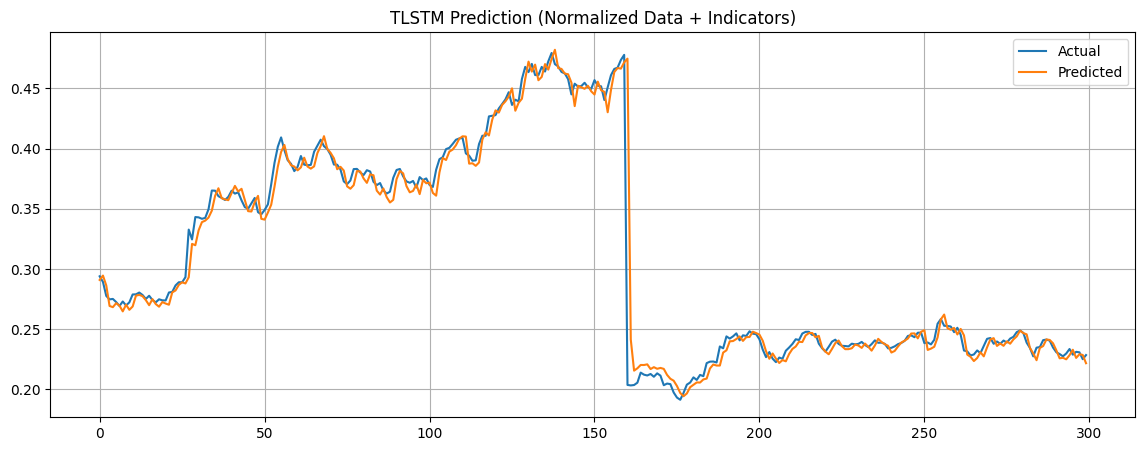

In [ ]:
tlstm.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for X, y, sem, _ in val_loader:
        X, y, sem = X.to(device), y.to(device), sem.to(device)
        X_aug = inject_sem(X, sem)
        pred = tlstm(X_aug)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

rmse = math.sqrt(mean_squared_error(y_true, y_pred))
print("Final RMSE:", rmse)

plt.figure(figsize=(14,5))
plt.plot(y_true[:300], label="Actual")
plt.plot(y_pred[:300], label="Predicted")
plt.title("TLSTM Prediction (Normalized Data + Indicators)")
plt.legend()
plt.grid(True)
plt.show()


RMSE in REAL PRICE SCALE (₹): 43.2550529915314


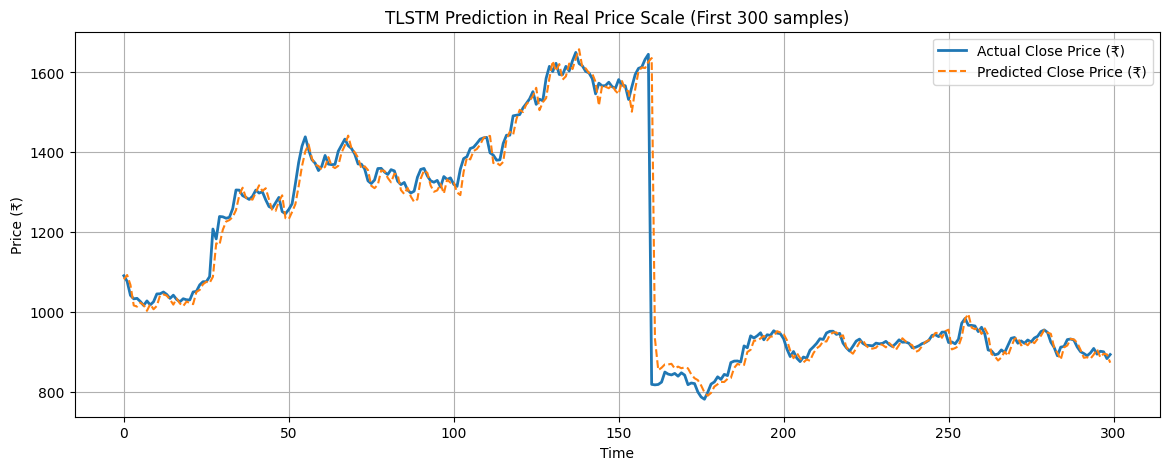

In [ ]:
# ============================================================
# STEP — Convert normalized predictions back to real prices
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.metrics import mean_squared_error

# scaler was defined earlier when normalizing stock_df

# Create empty arrays with 8 feature columns (because scaler expects full set)
y_true_arr = np.zeros((len(y_true), 8))
y_pred_arr = np.zeros((len(y_pred), 8))

# Fill ONLY the Close price column (index = 3)
y_true_arr[:, 3] = y_true
y_pred_arr[:, 3] = y_pred

# Inverse transform to original price scale
y_true_real = scaler.inverse_transform(y_true_arr)[:, 3]
y_pred_real = scaler.inverse_transform(y_pred_arr)[:, 3]

# Compute REAL RMSE (same as paper scale)
real_rmse = math.sqrt(mean_squared_error(y_true_real, y_pred_real))

print("======================================")
print("RMSE in REAL PRICE SCALE (₹):", real_rmse)
print("======================================")

# Plot real prices
plt.figure(figsize=(14,5))
plt.plot(y_true_real[:300], label="Actual Close Price (₹)", linewidth=2)
plt.plot(y_pred_real[:300], label="Predicted Close Price (₹)", linestyle="--")
plt.title("TLSTM Prediction in Real Price Scale (First 300 samples)")
plt.xlabel("Time")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)
plt.show()
